In [ ]:
import warnings
warnings.filterwarnings("ignore")    

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import anndata as ad

import pickle
import matplotlib


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig3"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))


In [3]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata=sc.read_h5ad(PATH2)
adata=adata[adata.obs["tech"]=="xenium"].copy()

In [4]:
adata.obs["Site_status"].value_counts()

Site_status
Non-lesional                        365837
Lesional                            231621
3D_Week12                           180311
3D_Lesional_baseline                153479
Week 12                             139631
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72094
Psoriasis_replicate_Lesional         60647
Healthy                              59315
Psoriasis_replicate_PostRx           49385
Day 14_HF                            30438
Name: count, dtype: int64

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [6]:
adata_5k_i=adata[adata.obs["disease_overall"]=="AD"]

In [7]:
adata.obs["Site_status"].value_counts()

Site_status
Non-lesional                        365837
Lesional                            231621
3D_Week12                           180311
3D_Lesional_baseline                153479
Week 12                             139631
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72094
Psoriasis_replicate_Lesional         60647
Healthy                              59315
Psoriasis_replicate_PostRx           49385
Day 14_HF                            30438
Name: count, dtype: int64

In [8]:
KEEP = list(adata[adata.obs["Sanger patient ID"]=="BK39"].obs["Site_status"].unique())
KEEP

['Lesional', 'Non-lesional', 'Week 12']

In [9]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["Site_status"].isin(KEEP)]

In [10]:

# adata_5k_i=adata
# colors = {'Adipocyte': '#B8860B',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',
#  'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#d3eec9',
#  'F4: TNN+COCH+': '#80ca80',
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1/2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#  'KC_cycling': '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#b1dae6',
#  'KC5': '#272c5f',
#  'KC_HF: Basal': '#006400',
#  'KC_HF: m': '#abe8bd',
#  'KC_HF: HS': '#abe8bd',
#  'KC_HF: IRS+HS': '#abe8bd',
#  'KC_SebocyteGland_Outer': '#fe5e00',
#  'KC_SebocyteGland_Inner': '#ffff33',
#  'KC_SebocyteDuct_Outer/HF_Junction': '#5C430F',
#  'KC_SebocyteDuct_Outer': '#958159',
#  'KC_SebocyteDuct_Inner': '#f6d7b0',
#  'KC_HF: ORS0': '#003200',
#  'KC_HF: ORS1': '#9ad295',
#  'KC_HF: ORS1/2': '#9ad295',
#  'KC_HF: ORS2': '#e7f9e5',
#  'KC_HF: IRS': '#ff083a',
#  'KC_HF: IRS_cycling': '#FF849D',
#  'KC: HF ORS1/2': '#94cb72',
#  'KC_HF: IRS+HS_medulla': '#94cb72',
#  'KC_HF: IRS_TCHH+': '#990523',
#  'KC_SC: LGR6+ACTA2+': '#008080',
#  'KCinflamm_basal/int': '#f4e9ef',
#  'KCinflamm_late': '#D49BB1',
#  'LC': '#63D7F0',
#  'LC_SLC18A2+': '#3bc1d9',
#  'LE': '#FFFF00',
#  'Mac': '#845DAE',
#  'Mac2': '#845DAE',
#  'Mac2_CCL14hi': '#4F2F6D',
#  'Mast cell': '#f8ac59',
#  'Melanocyte': '#6f3a3a',
#  'MigDC': '#00FF00',
#  'MigDC (cDC2)': '#00FF00',
#  'MigDC (cDC1)': '#FF9999',
#  'Smooth muscle': '#f371af',
#  'Nonspecific': '#D3D3D3',
#  'Pericyte1': '#F7A3C3',
#  'Pericyte2_VSMC': '#D04A8A',
#  'Plasma cell': '#ff5e00',
#  'KC_Sebocyte_basal': '#e28743',
#  'KC_Sebocyte_inner': '#ffd1a3',
#  'KC_Sebocyte': '#ffd1a3',
#  'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': '#FFE5B4',
#  'Sweat gland channel inner': '#FFE5B4',
#  'Sweat gland channel_outer': '#B3FFF0',
#  'Sweat gland channel outer': '#B3FFF0',
#  'Sweat gland Myoepithelial': '#f275ae',
#  'T': '#F4D1A1',
#  'T_Prolif': '#D4B082',
#  'Tc': '#8C6A3B',
#  'Tc1': '#8C6A3B',
#  'Tc2': '#8C6A3B',
#  'Tc_IL9R+GPR15hi': '#5a1f16',
          
#  'Tnaive': '#F9F2E4',
#  'Treg': '#B2CBA4',
#  'Treg_LRRC32+': '#68984c',
#  'VE2': '#9f1a1a',
#  'VE': '#9f1a1a',
#  'VE1_Art': '#660000',
#  'VE3_Ven': '#764869',
#  'VE4_Cap': '#FFB6C1',
#  'VE3_Ven_APLN+': '#FF073A',
#  'cDC1': '#ac1d5c',
#  'cDC2': '#6F478C',
#  'cDC2: MMP12hi': '#f71886',
#  'mSchwann': '#555555',
#  'nmSchwann': '#999999',
#  'pDC': '#D85B8C',
#  'cDC2: EREG+CCR7+': '#7B8B43',
#  'TransitionalDC': '#9b4ef5',
#  'Bcell':  "#1E90FF",  # DodgerBlue – not already used
#  'Cartilage': '#404040',
#  'F4: DP_HHIP+': '#26a83f',
#  'F4: HF-associated': '#26a83f',
#  'F_Fascia': '#000000',
#  'ILC1': '#FFFF00',
#  'ILC1_NCR2+P2RX7+': '#c18bcb',
#  'ILC1_NK': '#F4D03F',
#  'ILC1/NK': '#F4D03F',
#  'ILC2': '#F1C40F',
#  'ILC2/3': '#F1C40F',
#  'ILC3': '#C79A00',
#  'ILC3 CCL1+PTGDS+': '#ff68b4',
#             'ILC3_CCL1+PTGDS+': '#ff68b4',

#  'ILC_Prolif': '#3F3100',
#  'ILC_prolif': '#3F3100',
#  'KC1': '#3a4e7a',
#  'KC2': '#505aa1',
#  'KC_HF: ORS_cycling': '#00b300',
#  'KC_HF: Basal_NPNT+': '#006400',
#  'KC_HF': '#006400',
#  'KCinflamm_basal': '#f9f3fb',
#  'KCinflamm': '#f9f3fb',
#  'KCinflamm_int/late': '#e9c8dc',
#  'KCinflamm_cycling': '#e0c5d2',
#  'KC1-2_cycling': '#e0c5d2',
#  'KCinflamm_int': '#f5d3e7',
#  'LC_CCR7+': '#3bc1a4',
#  'Mac1': '#6A3F9B',
#  'Mac_CX3CR1+': '#9D1A80',
#  'Mac_TREM2+LPL+': '#D2C5E1',
#  'Merkel cell': '#2f2f2f',
#  'MoDC': '#7F00A2',
#  'MoDC/cDC2: MMP12+': '#7F00A2',
#  'MoDC/cDC2': '#7F00A2',
#  'Monocyte': '#D8A7FF',
#  'Mono CD16+': '#E1C6FF',
#  'NK': '#FF00FF',
#  'Neutrophil': '#4D3F8C',
#  'Satellite cell': '#F387C7',
#  'Skeletal muscle': '#F14D8E',
#  'Tc_IFNGhi': '#F5A600',
#  'Tc3_IFNGhi': '#F5A600',
#  'TRM_IL13+': '#7795cc',
#  'TRM_IL17+': '#E63238',
#  'Tc_ZNF683+': '#D4B082',
#  'Th': '#F9CA67',
#  'Th_PPARGhi': '#FAE064',
#  'Th_CXCR6+': '#F48B50',
#  'TR1': '#E3F2DC',
#  'cDC2: IL1B+': '#B78FE1',
#  'cDC2_cycling': '#9272B4',
#  'Eosinophil': '#FF5F00',
#  'Mechanoreceptor ASIC2+': '#D3D3D3',
#            'ASIC2+_Mechanoreceptor':  '#D3D3D3',
#  'Tc_γδ': '#28c1d0',
#       'T_γδ': "#28c1d0",

#  'Tc0': '#5a1f16',
#  'Th_PPARGhi_IL17': '#FFE064',
#  'Tfh-like': '#d8e4e2',
#  'Th2': '#b8bde3',
#  'ILC3_prolif': '#503E00',
#  'ILC1_prolif': '#666600',
#  'ILC_SELL+CCR7+': '#FFFFCC',
         
         
# #          "KC_HF: IRS_Cuticle":        "#E97388",
    
# #         "KC_HF: HS Xenium":     "#0000FF",
# #     "KC_HF: HS":           "#8A0C26",
    
    
# #  "KC_HF: HS scRNA":      "#FF69B4",
    
# #     "Other":                "#F3F3F3",
    
    
   


# #     "KC_HF: ORS0":          "#006400",
# #     "KC_HF: ORS1":          "#66C266",
# #     "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
# #     "KC_HF: ORS_cycling":    "#267326" , #"#000000",
# #         "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
# #         "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
# #     "KC_HF: IRS":           "#0000FF",
# #     "KC_HF: IRS0":          "#FFA500",
# #     "KC_HF: IRS1":          "#FFD280",
# #    # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
# #     "KC_HF: IRS_cycling":   "#00F5FF",

# #     'KC_SebocyteDuct_Outer':   "#FF69B4",
# #     #e6ecf0
# #     "KC_HF: ORS cycling(new)":   "#1A1A1A",
# #     "KC_HF: HFSC":               "#D600FF",
  
    
# #     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
# #     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
# #     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
# #     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
# #     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
# #     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
# #         'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

# #     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
# #      'Sweat gland': '#00CCCC',
# #  'Sweat gland channel': '#2DA8A0',
# #  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
# #          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # # 'Sweat gland channel outer': 'Sweat gland channel outer',
# #  'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
# #         'Sweat gland channel outer': "#99EEEE",
# #                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
#          'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
#  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
#         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
#          "F4: HF-associated": "#26a83f",
#     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
#      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
   
# #   "KC_HF/Sebocyte_Junction/inner duct": "#00F7F7", # "#8|B4513",  # brown   (saddle-brown)
# #     "KC_HF: ORS2/IRS":                     "#FF0000",  # peach   (pale peach)
# #         "KC_HF: ORS2i":                     "#FF0000",  # peach   (pale peach)

# #     "KC_HF: ORS1? ?bulb/infundibulum":     "#87CEEB",  # neon yellow
# #     'KC_HF: ORS-?bulb/infundibulum': "#87CEEB",  
# #     "KC_HF: ORS0 (lowq)":                  "#4D4D4D",  # dark grey

# #     "KC_HF: ORS0":          "#006400",
# #     "KC_HF: ORS1":          "#66C266",
# #     "KC_HF: ORS2":          "#FFDDC1",
# #     "KC_HF: ORS_cycling":   "#F3FFF3", #"#000000",
# #     "KC_HF: IRS":           "#0000FF",
# #     "KC_HF: IRS0":          "#FFA500",
# #     "KC_HF: IRS1":          "#FFFF00",
# #     "KC_HF: IRS2":          "#FF69B4",      # "#008000",
# #     "KC_HF: IRS_cycling":   "#00F5FF",
# #     "KC_HF: HS Xenium":     "#0000FF",
# #     "KC_HF: HS":            "#C10037",
# #  "KC_HF: HS scRNA":      "#FF69B4",
# #     'KC_SebocyteDuct_Outer':   "#FF69B4",
# #     #e6ecf0
# #       "KC_HF: ORS_junction2inner": "#32CD32",
# #     "KC_HF: ORS_junction":       "#39FF14",
# #     "KC_HF: ORS cycling(new)":   "#1A1A1A",
# #     "KC_HF: HFSC":               "#D600FF",
# #     "KC_HF: IRS_Cuticle":        "#D8B7FF",
    
# #     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
# #     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
# #     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
# #     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
# #     "KC_Sebocyte_DuctInner ?JUNCTION":       "#FF69B4",  # pink
# #     'KC_Sebocyte_DuctInner_Junction':  '#f371af',   # like mnuscle color "#FF69B4", 
# #    'KC_HF: IRS_Sebo_doublet?':                 "#4D4D4D",  # dark grey
# #     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
# #     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
# #     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
# #      'Sweat gland': '#00CCCC',
# #  'Sweat gland channel': '#2DA8A0',
# #  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
# #          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # # 'Sweat gland channel outer': 'Sweat gland channel outer',
# #  'Sweat gland channel_outer': "#80FFE0",#'#40E0D0',
# #         'Sweat gland channel outer': "#B3FFF0",
# #                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
# #      'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
# #  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
# #         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
# #          "F4: HF-associated": "#26a83f",
# #     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
# #      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
    
# #         "KC_HF: ORS-Bulb/infundibulum": "#B4E91A" ,
# #              "Other": '#D3D3D3'
          
#                 "KC_HF: IRS_Cuticle":        "#E97388",
    
#         "KC_HF: HS Xenium":     "#0000FF",
#     "KC_HF: HS":           "#8A0C26",
    
    
#  "KC_HF: HS scRNA":      "#FF69B4",
    
#     "Other":                "#F3F3F3",
    
    
   


#     "KC_HF: ORS0":          "#006400",
#     "KC_HF: ORS1":          "#66C266",
#     "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
#     "KC_HF: ORS_cycling":    "#267326" , #"#000000",
#         "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
#         "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
#     "KC_HF: IRS":           "#0000FF",
#     "KC_HF: IRS0":          "#FFA500",
#     "KC_HF: IRS1":          "#FFD280",
#    # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
#     "KC_HF: IRS_cycling":   "#00F5FF",

#     'KC_SebocyteDuct_Outer':   "#FF69B4",
#     #e6ecf0
#     "KC_HF: ORS cycling(new)":   "#1A1A1A",
#     "KC_HF: HFSC":               "#D600FF",
  
    
#     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
#     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
#     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
#     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
#     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
#     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
#         'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

#     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
#      'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
#          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
#         'Sweat gland channel outer': "#99EEEE",
#                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
#          'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
#  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
#         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
#          "F4: HF-associated": "#26a83f",
#     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
#      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
         
#          'KC3-5': '#b1dae6',
#           'KC1-2': '#505aa1',
#           'TRM': '#E63238',
#           'KC_Sebocyte_Duct':  "#C8A165", 
#           'KC_Sebocyte_Gland': "#FFFFCC", 
#           'KC_HF: ORS/IRS/HS':'#9ad295',
#           'Schwann': '#555555',
#           'Sweat gland/duct': '#00CCCC',
#           'F5: Schwann-like': '#788bd2',
#           'KC_HF: ORS/IRS': '#9ad295',
#           'Pericyte': '#F7A3C3',
#           'KC_Sebocyte_Duct/Gland':  "#FFFFCC",
#           'ILC':  '#F1C40F',
         

# }



# #del(adata.uns['lvl3_annotation_colors'])
# adata.obs['scanvi_predictions'] =adata.obs['scanvi_predictions'] .astype('category')
# adata.uns['scanvi_predictions_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['scanvi_predictions'].cat.categories]



In [11]:
# import matplotlib.pyplot as plt
# import squidpy as sq
# import scanpy as sc
# import numpy as np
# import pandas as pd

# # ─────────────────────────────────────────────────────────────
# # 0 · plotting defaults
# # ─────────────────────────────────────────────────────────────
# sc.settings.set_figure_params(
#     dpi=100, facecolor="white", frameon=False, figsize=(6, 5)
# )

# # ─────────────────────────────────────────────────────────────
# # 1 · choose patients to plot  (>1000 total cells)
# # ─────────────────────────────────────────────────────────────
# pat_counts  = adata_5k_i.obs["Sanger patient ID"].value_counts()
# patients    = sorted(pat_counts.loc[lambda s: s > 1000].index)   # deterministic order

# # site-status order you want left→right  (edit to taste)
# SITE_STATUSES = [
#     "Lesional",
#     "Non-lesional",
#     "Week 12",
# ]

# # ─────────────────────────────────────────────────────────────
# # 2 · iterate patients
# # ─────────────────────────────────────────────────────────────
# for pat_id in patients:
#     adata_pat = adata_5k_i[adata_5k_i.obs["Sanger patient ID"] == pat_id].copy()

#     # figure: one row, three columns
#     fig, axes = plt.subplots(
#         1, 3,
#         figsize=(12, 4),
#         constrained_layout=True,
#         sharex=False, sharey=False,
#     )

#     for ax, status in zip(axes, SITE_STATUSES):
#         mask = adata_pat.obs["Site_status"] == status
#         if mask.sum() == 0:
#             ax.set_axis_off()
#             ax.set_title(f"{status}\n(no data)", fontsize=8)
#             continue

#         adata_sub = adata_pat[mask]

#         sq.pl.spatial_scatter(
#             adata_sub,
#             library_id="spatial",
#             shape=None,
#             color="lvl4_annotation",
#             size=5,
#             vmax=2,
#             cmap="Reds",
#             edgecolor="black",
#             linewidth=0.03,
#             legend_loc=None,
#             ax=ax,
#         )
#         ax.set_title(f"{status}\n{len(adata_sub):,} cells", fontsize=9)

#     # global row title
#     fig.suptitle(
#         f"Sanger patient ID: {pat_id}",
#         fontsize=12, y=1.04
#     )
#     plt.show()

In [12]:
adata_5k_i.obs["Sanger patient ID"].value_counts()

Sanger patient ID
BK49    64944
BK39    64938
BK23    53364
BK51    53204
BK30    49044
BK18    40442
BK25    39148
BK46    37107
BK24    36288
BK22    30719
BK21    30613
BK27    29908
BK50    24473
BK20    24053
BK43    18993
Name: count, dtype: int64

In [13]:
with open('/nfs/team298/ls34/niche_colors.pkl', 'rb') as f:
    colors_new2 = pickle.load(f)


In [14]:
adata_5k_i.obs['niche19'] =adata_5k_i.obs['niche19'] .astype('category')
adata_5k_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k_i.obs['niche19'].cat.categories]

/tmp/ipykernel_3545259/1360001178.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k_i.obs['niche19'] =adata_5k_i.obs['niche19'] .astype('category')


In [15]:
# """
# find niche
# """

# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(6,5))

# sample_counts = adata_5k_i.obs["Sanger patient ID"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index

# ORDER = []
# for i,DONOR_ID in enumerate(["CE3", "BK39", "CE4", "BK23"]):
#    # print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["Sanger patient ID"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id2.unique())[0]
#     print(INFO_ID)
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   

# #             print(tissue_section_id)
#    # adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="CCL19",
#         size=5,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#         #legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.03,
#                 legend_fontsize=12,
#         cmap="Reds",
#                 vmax=2,

    

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break
#     adata_i.obs["niche19"]=[x if x.startswith("Tz") else "Other" for x in adata_i.obs["niche19"]]
#     adata_i.uns.pop('niche19_colors')
#     adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
#     adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_i.obs['niche19'].cat.categories]
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche19",
#         size=5,
#         title="",
#         #title=INFO_ID, #+ "_nonlesional",
#         legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.01,
#                 legend_fontsize=12,
#         #cmap="Reds",
#                # vmax=2,

    

       
#     )


In [16]:
adata.obs["Site_status"].value_counts()

Site_status
Non-lesional                        365837
Lesional                            231621
3D_Week12                           180311
3D_Lesional_baseline                153479
Week 12                             139631
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72094
Psoriasis_replicate_Lesional         60647
Healthy                              59315
Psoriasis_replicate_PostRx           49385
Day 14_HF                            30438
Name: count, dtype: int64

In [17]:
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(20,20))

# adata=adata[adata.obs["Site_status"]=="Week 12"]
# for x in adata.obs["Sanger patient ID"].unique():
#     adata_i=adata[adata.obs["Sanger patient ID"]==x]
#     #adata_i=adata_i[adata_i.obs["Site_status"]=="Week 12"]

#     # adata_i.obs['niche17'] =adata_i.obs['niche17'] .astype('category')
#     # adata_i.uns['niche17_colors'] = [colors_loaded.get(cat, '#D3D3D3')   
#     #                                      for cat in adata_i.obs['niche17'].cat.categories]
#     # adata_i.obs['niche17_alt2'] =adata_i.obs['niche17_alt2'] .astype('category')
#     # adata_i.uns['niche17_alt2_colors'] = [colors_loaded.get(cat, '#D3D3D3')   
#     #                                      for cat in adata_i.obs['niche17_alt2'].cat.categories]
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["lvl5_annotation"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12,
#         title=x,
#         legend_loc=None
       
#     )
  

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


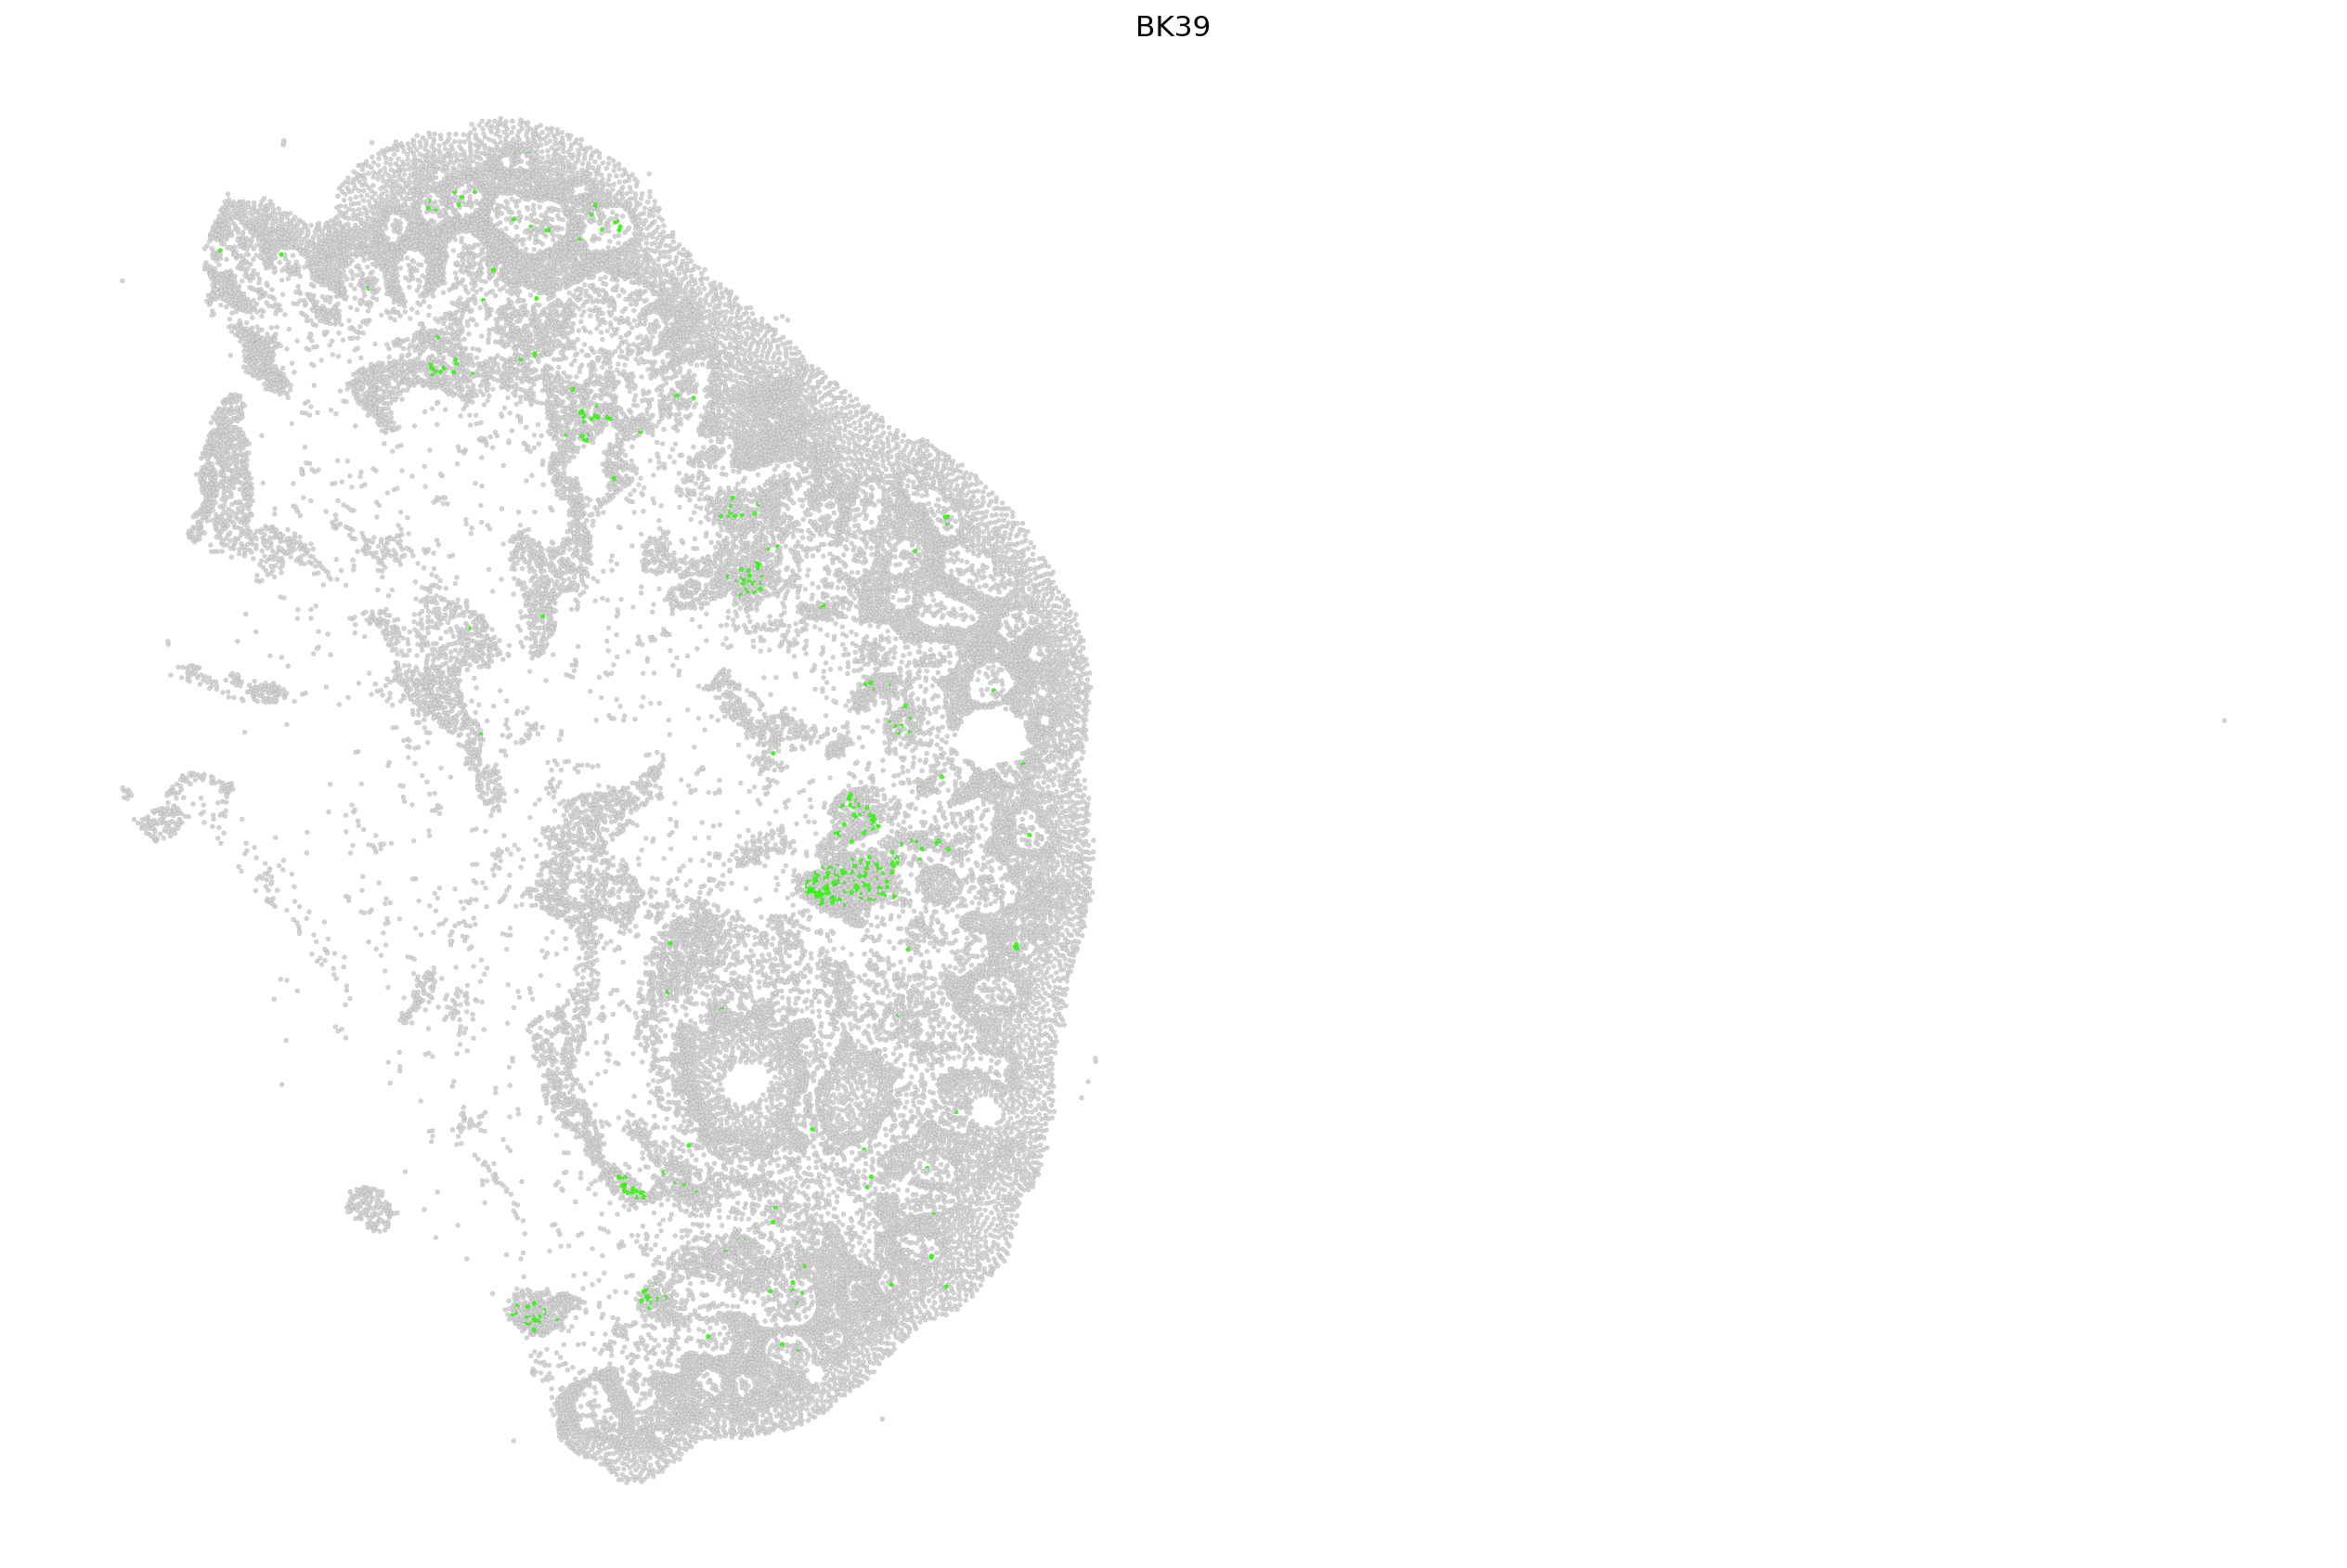

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


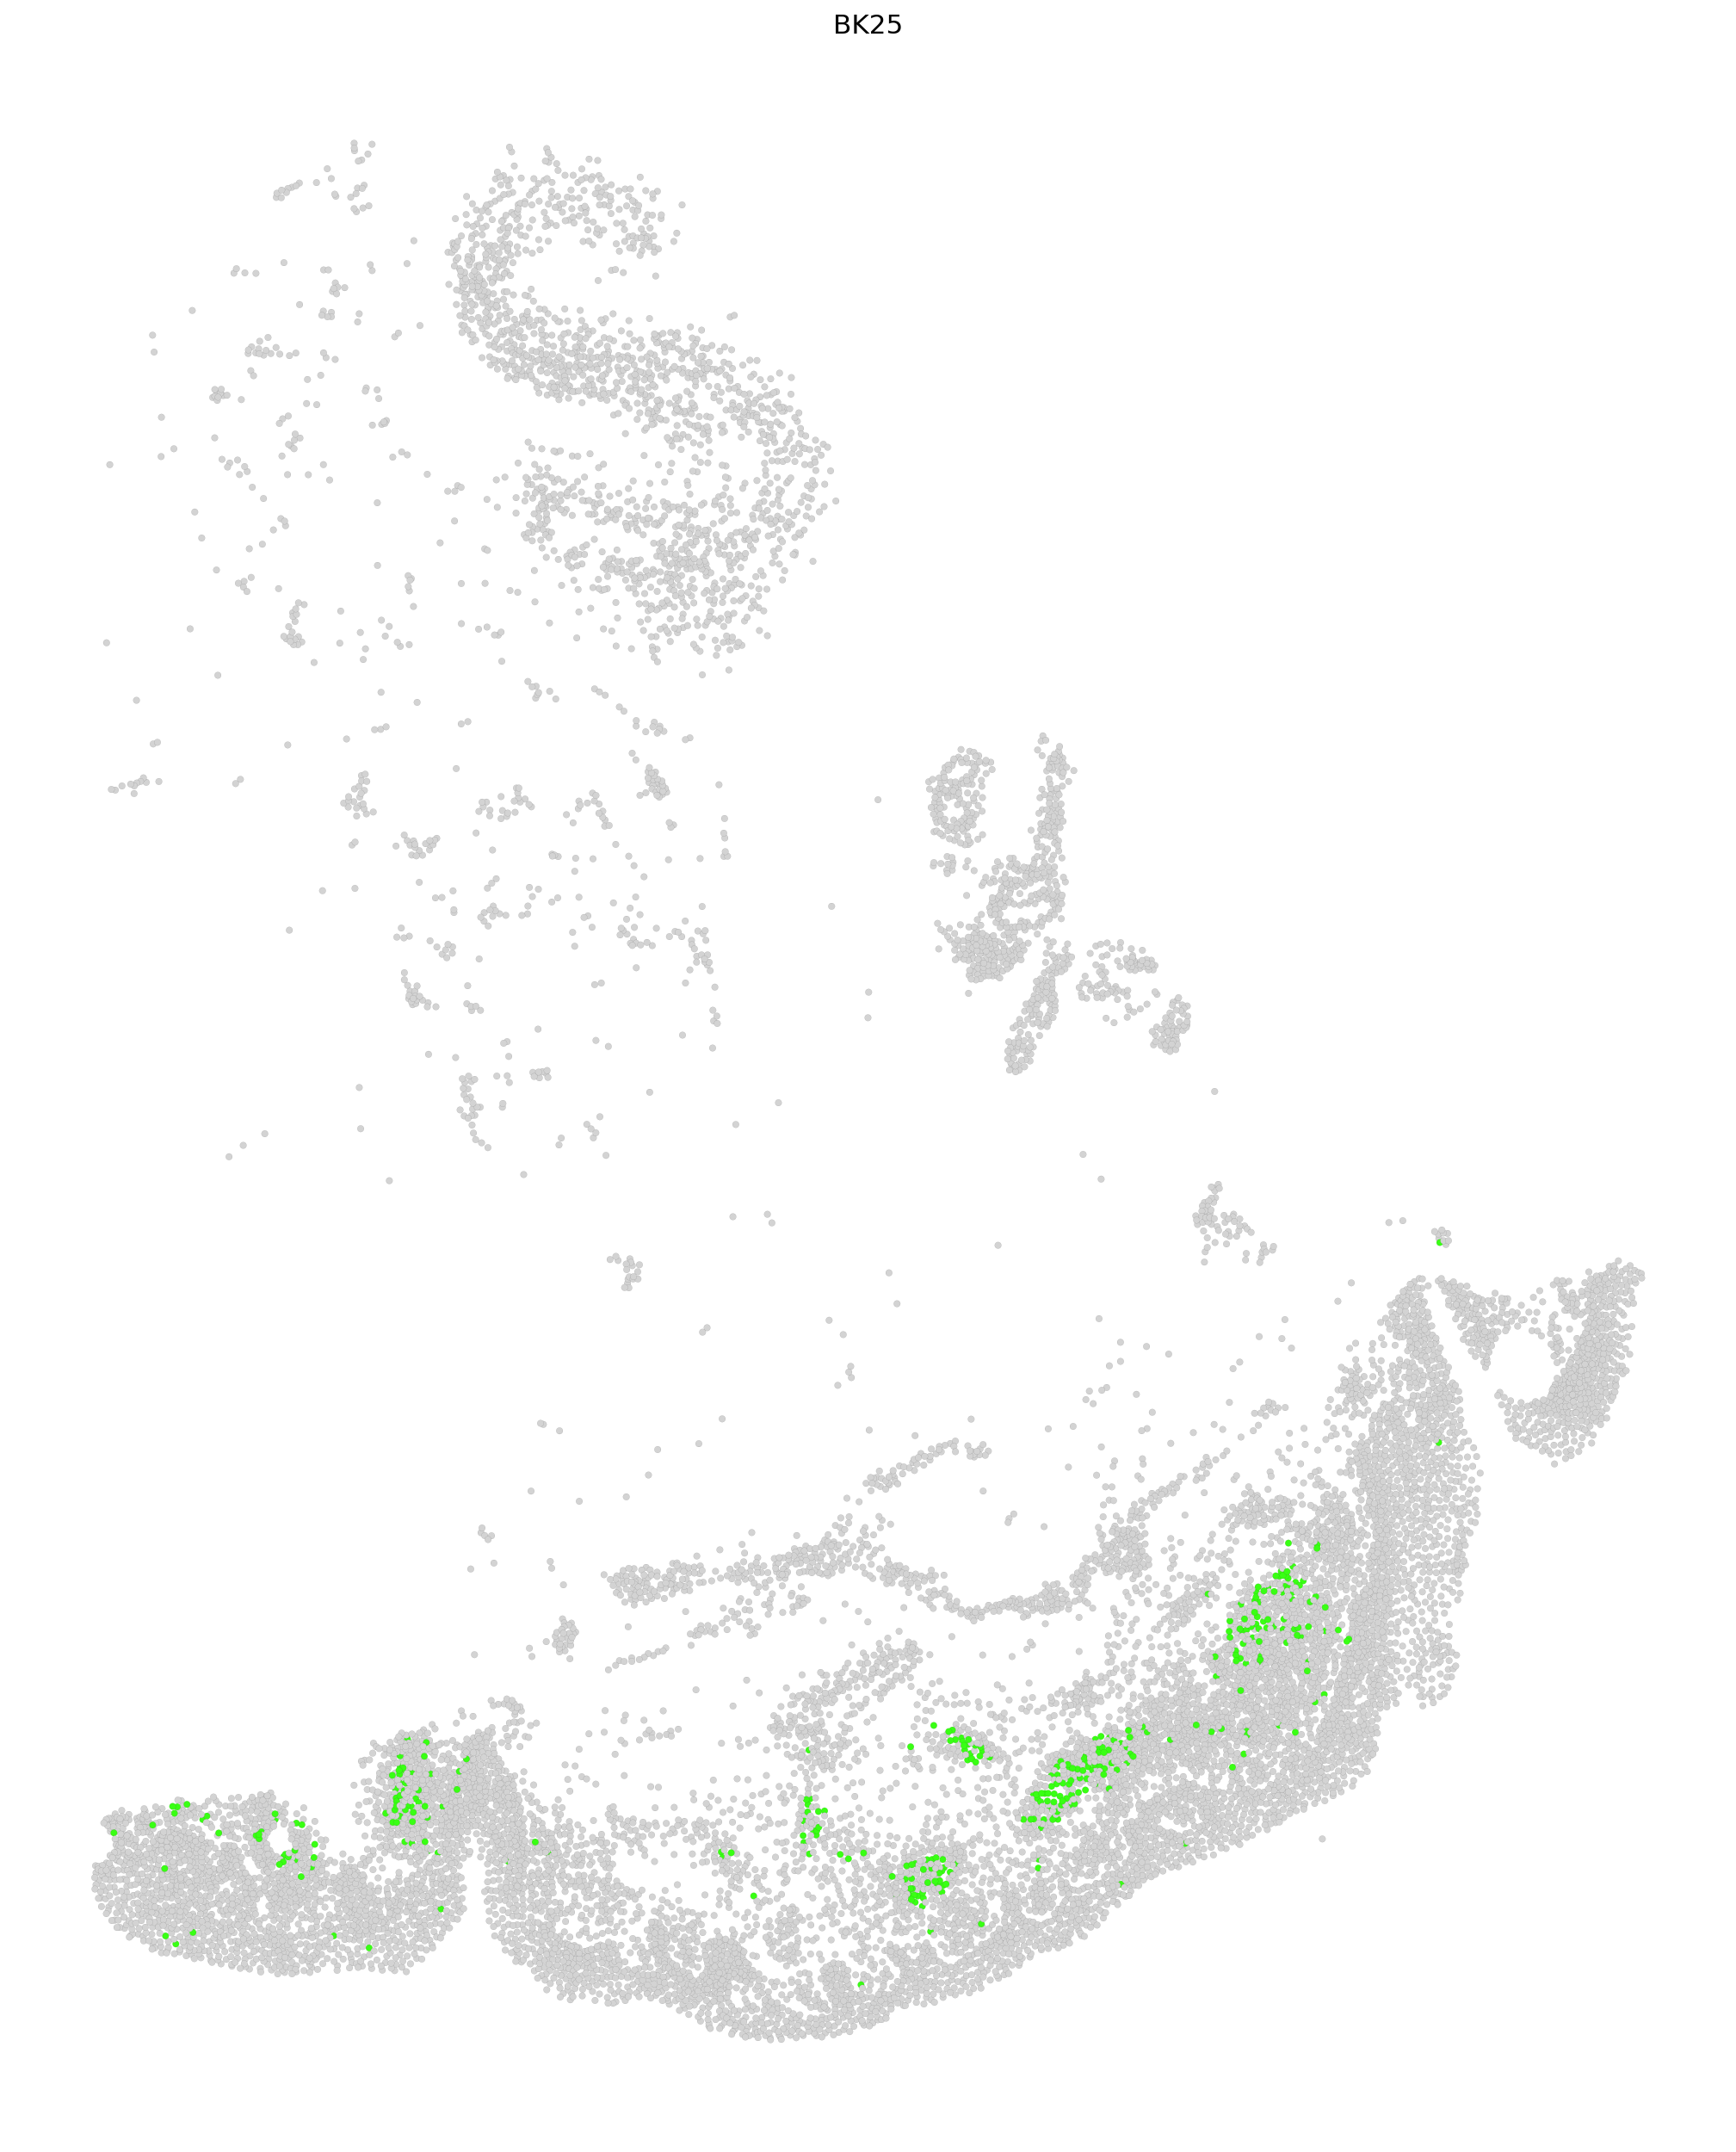

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


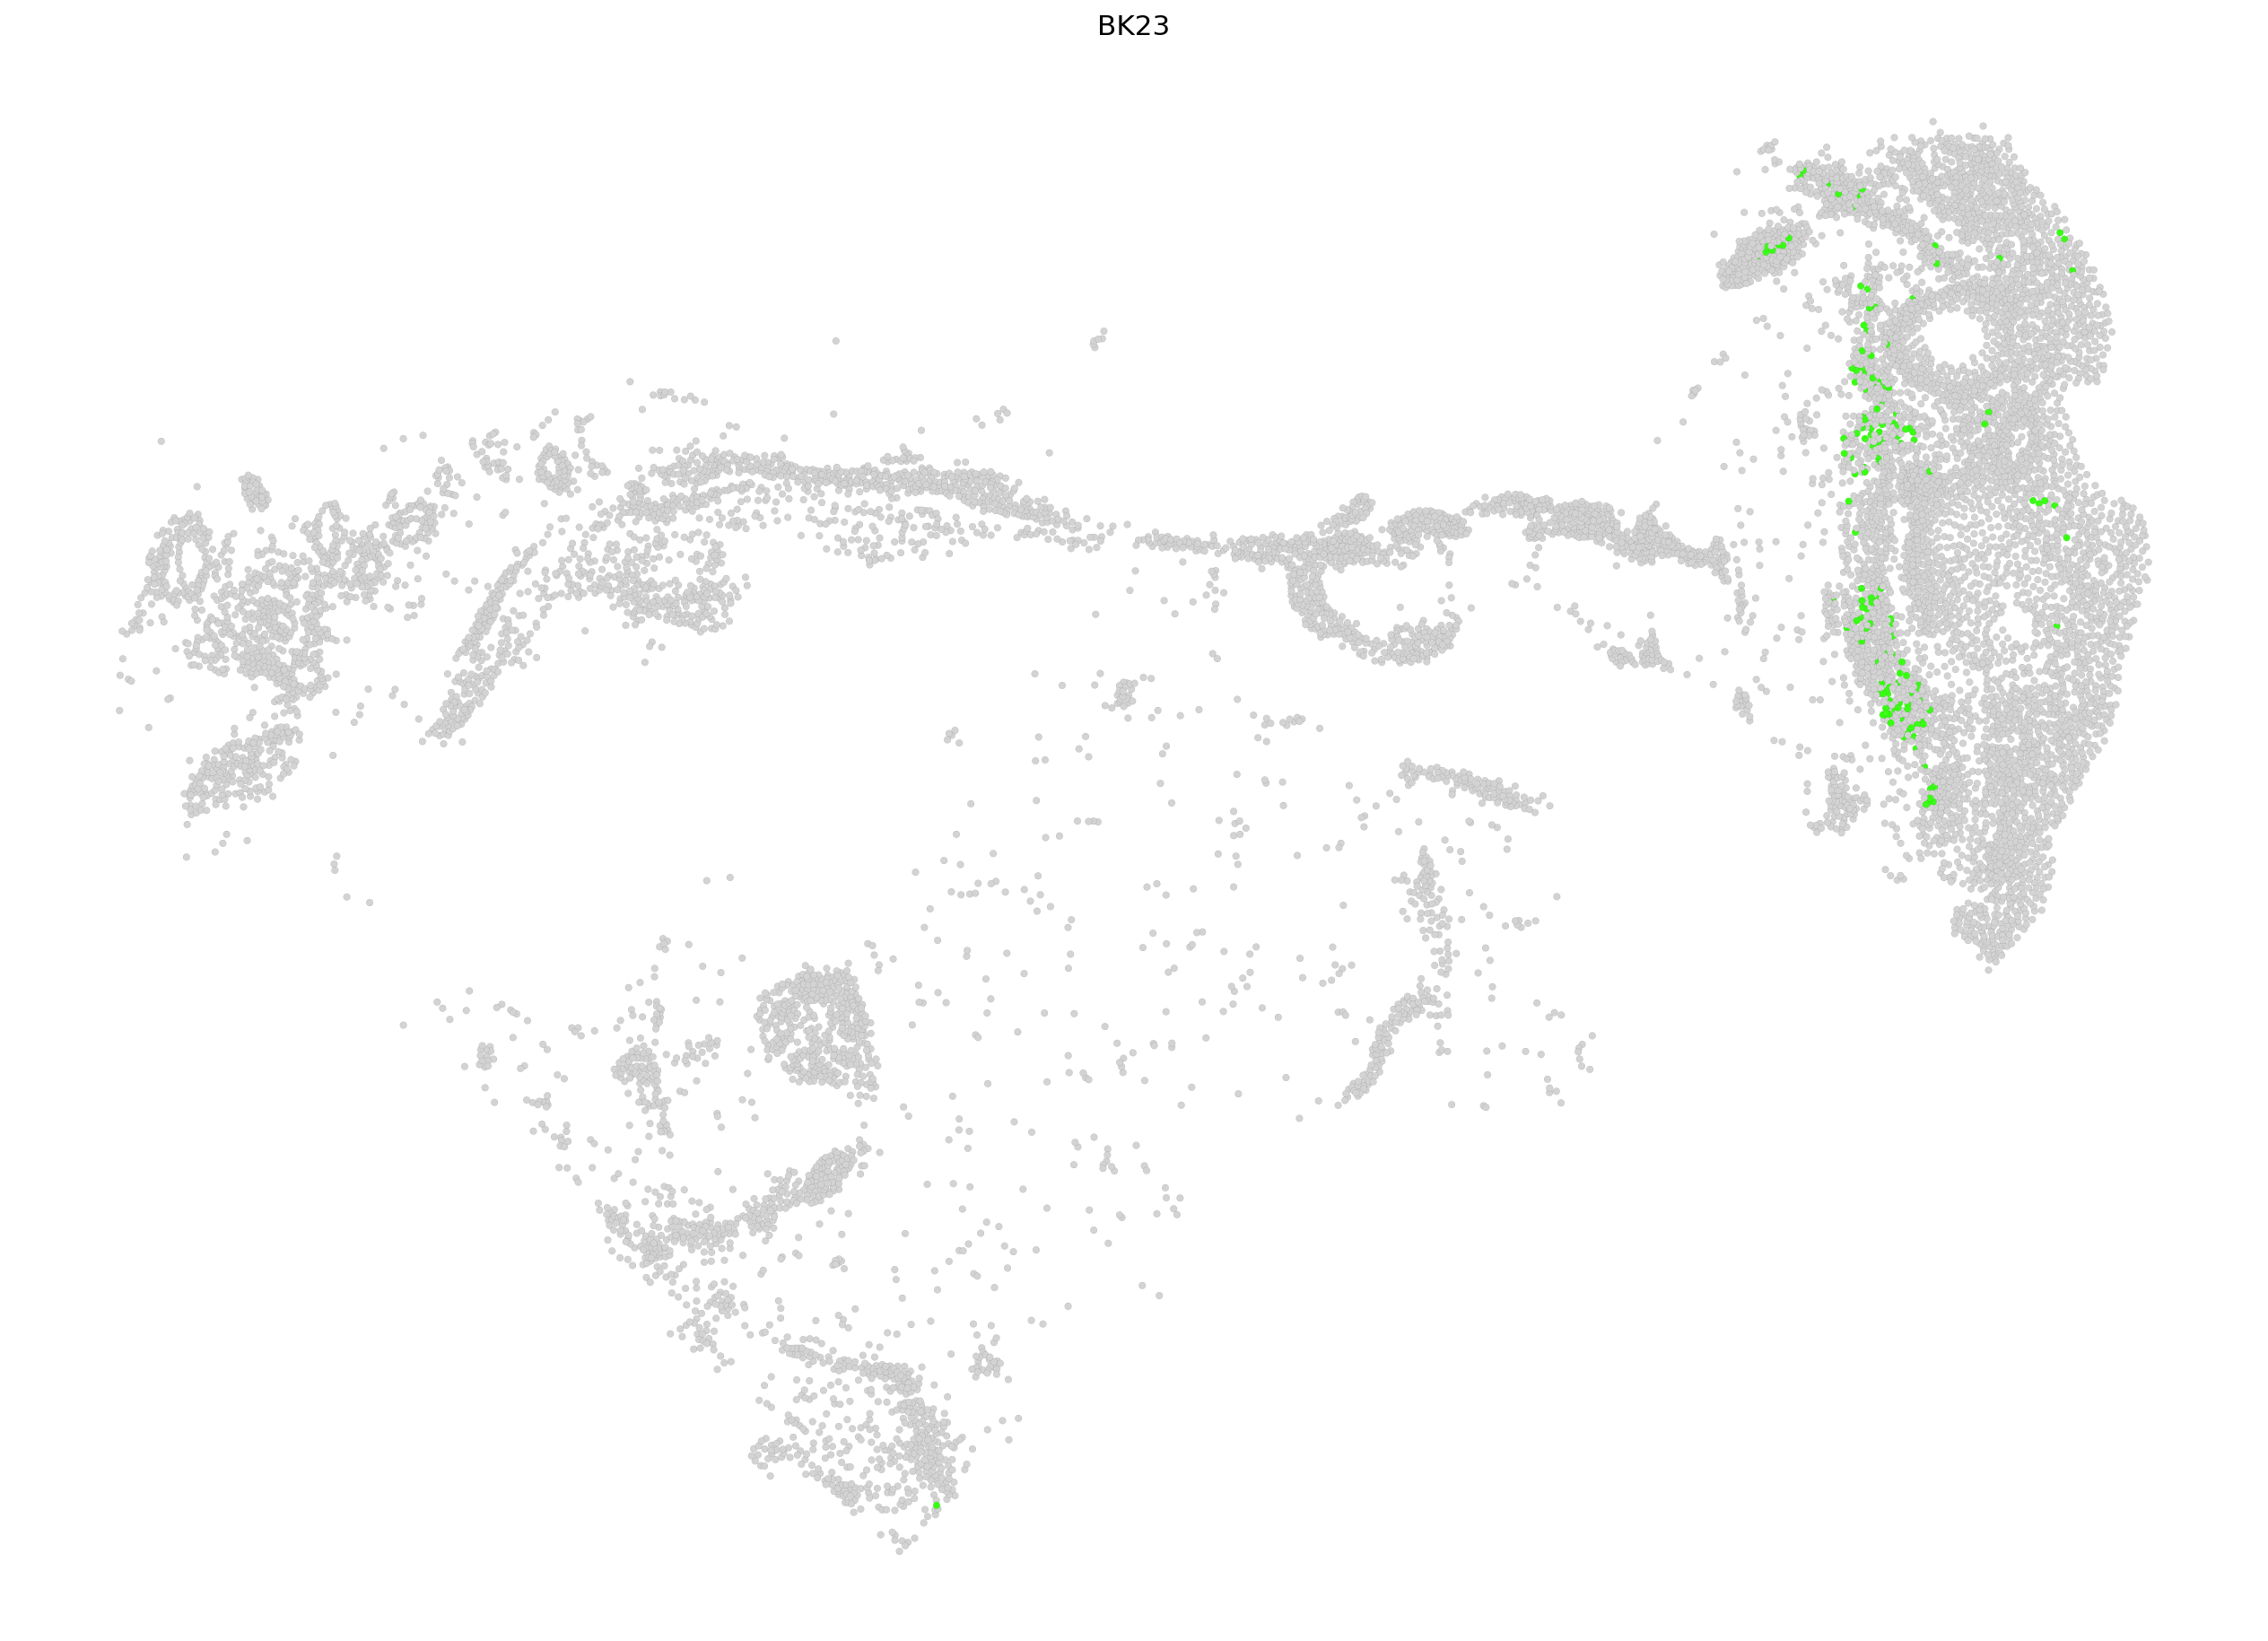

In [18]:
target = "MigDC (cDC2)"
highlight_color = "#39FF14"   # neon green
background_color = "#D3D3D3"  # light grey

adata_filt = adata[adata.obs["Site_status"] == "Week 12"]

#for x in adata_filt.obs["Sanger patient ID"].unique():
for x in ['BK39', 'BK25', 'BK23']:
    adata_i = adata_filt[adata_filt.obs["Sanger patient ID"] == x].copy()

    # Make a binary annotation column
    adata_i.obs["highlight"] = [
        target if y == target else "Other" 
        for y in adata_i.obs["lvl5_annotation"]
    ]
    adata_i.obs["highlight"] = adata_i.obs["highlight"].astype("category")

    # Assign colors: one for target, one for all others
    adata_i.uns["highlight_colors"] = [highlight_color, background_color]

    sc.pl.spatial(
        adata_i,
        color="highlight",
        spot_size=12,
        vmax=1,
        edgecolor="black",
        linewidth=0.03,
        legend_fontsize=12,
        title=x,
        legend_loc=None,
        save=f"3k_week12_{x}.pdf"
    )

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


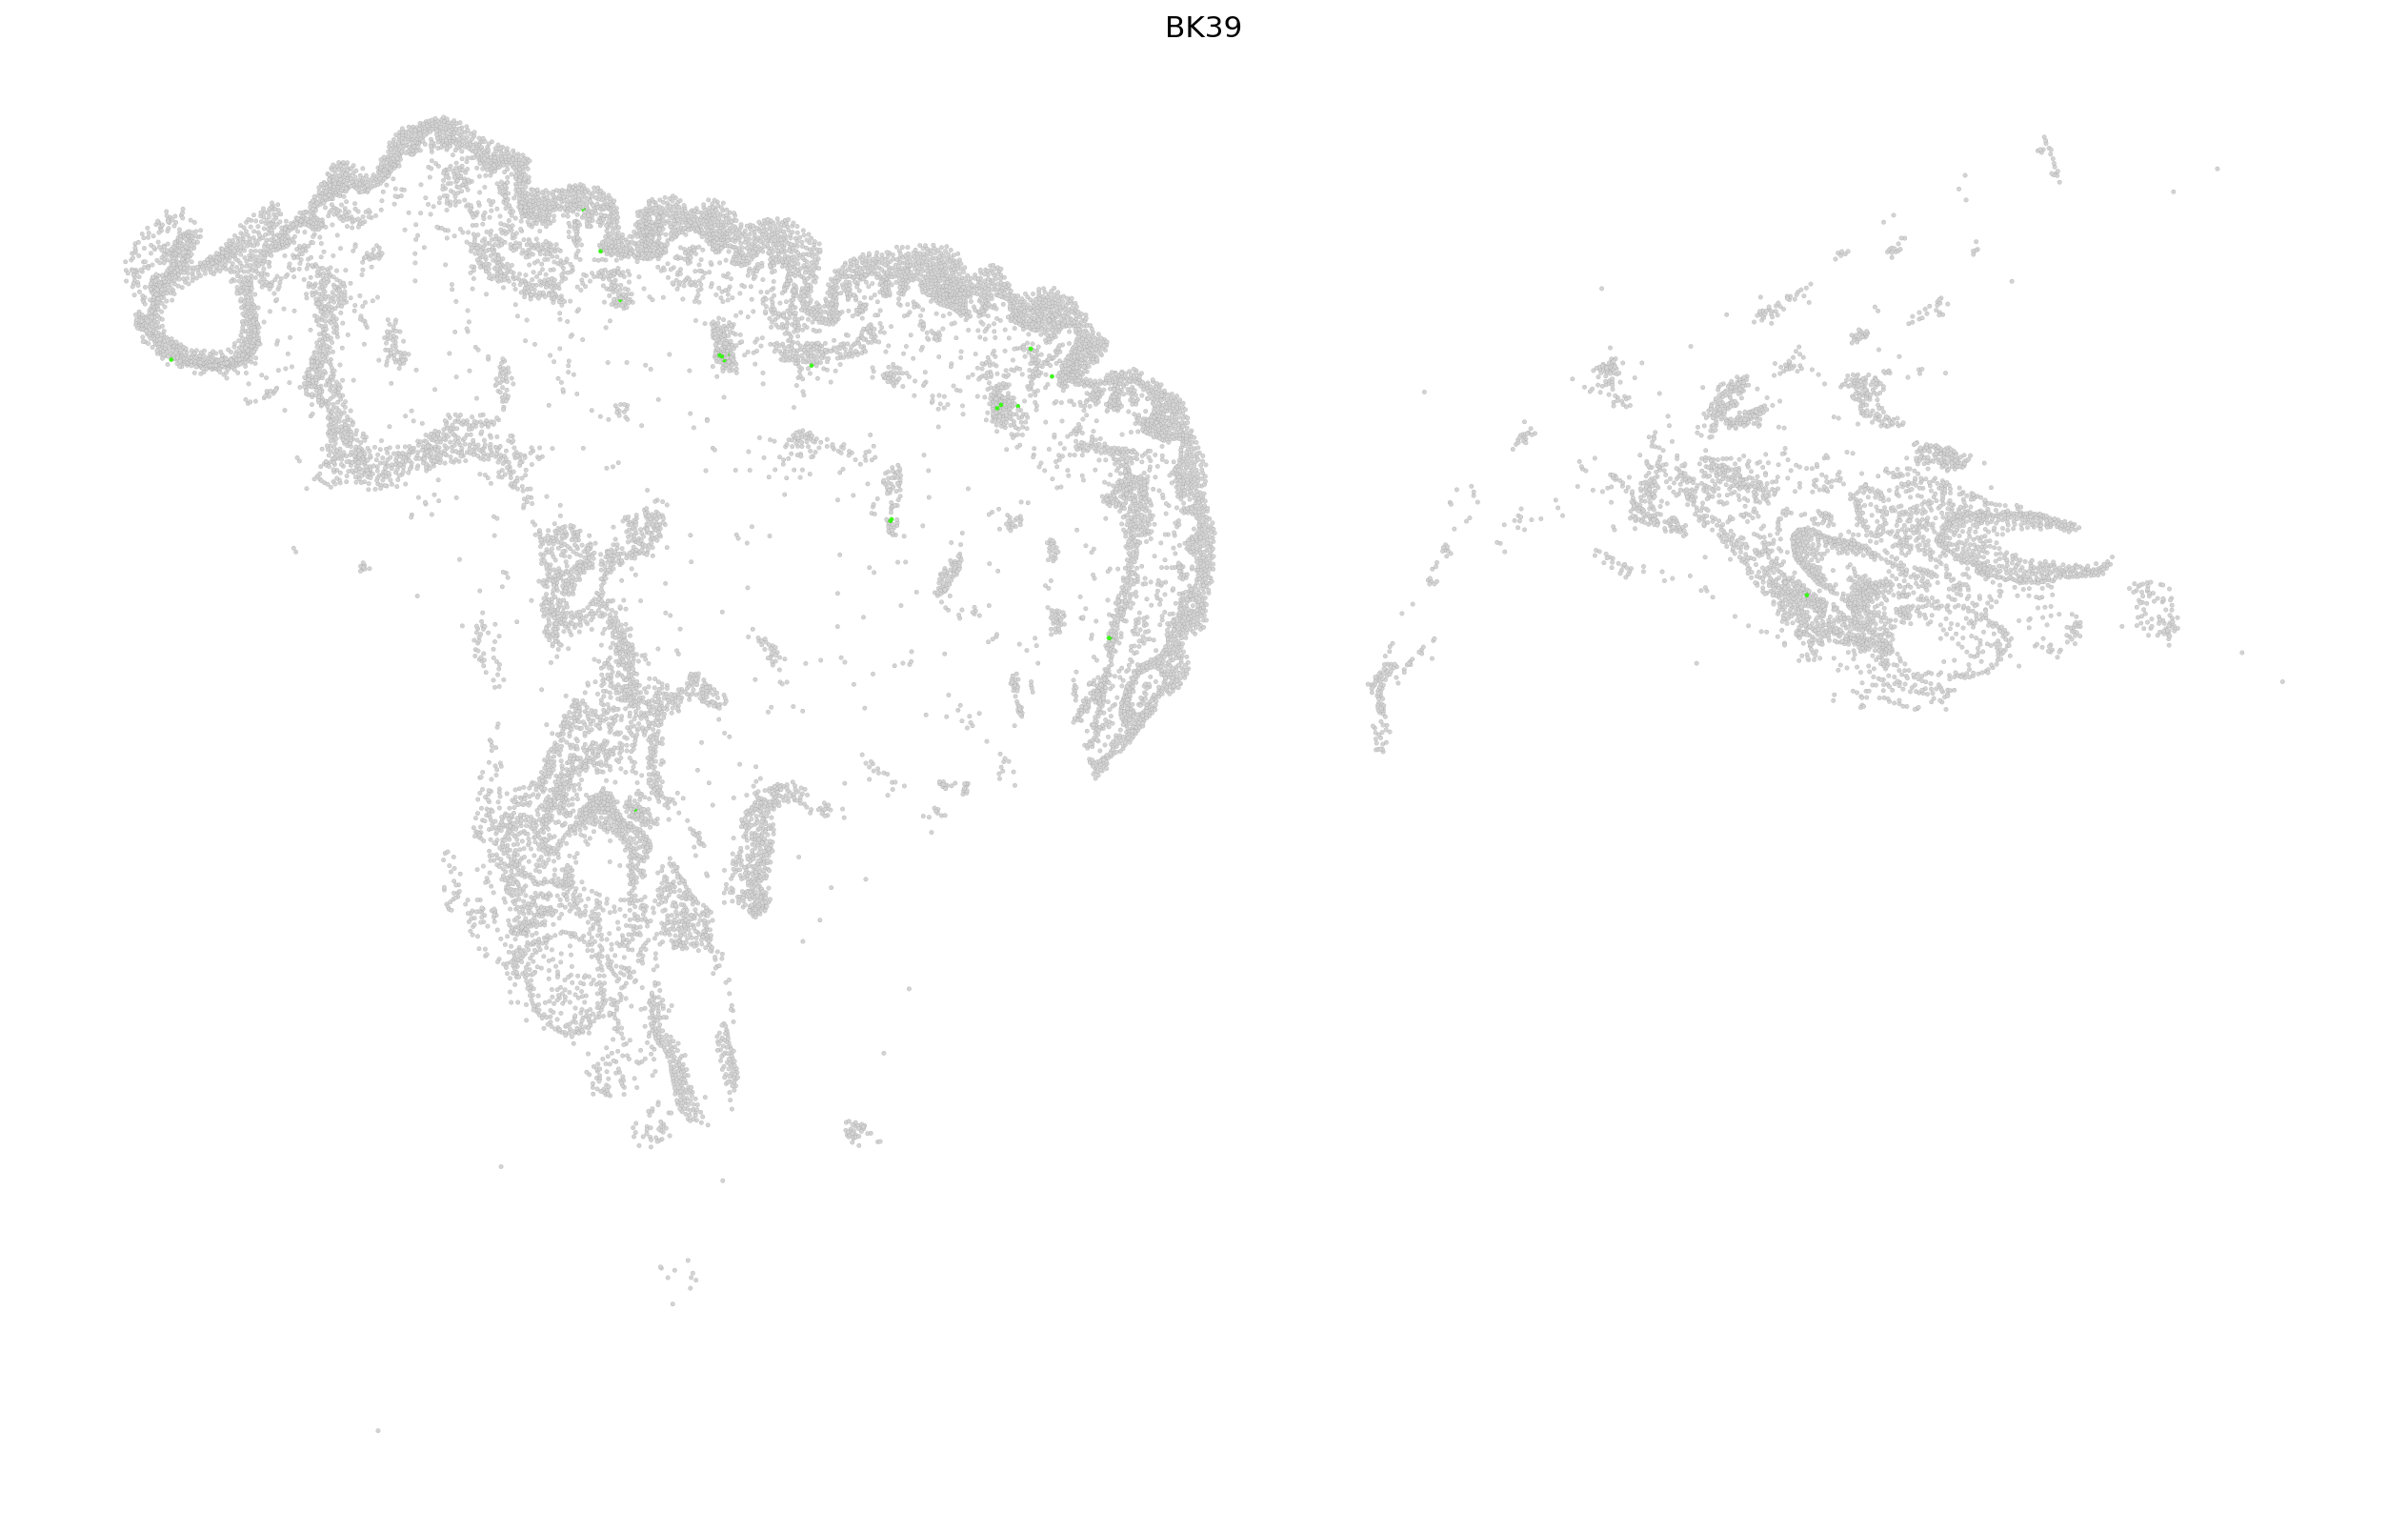

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


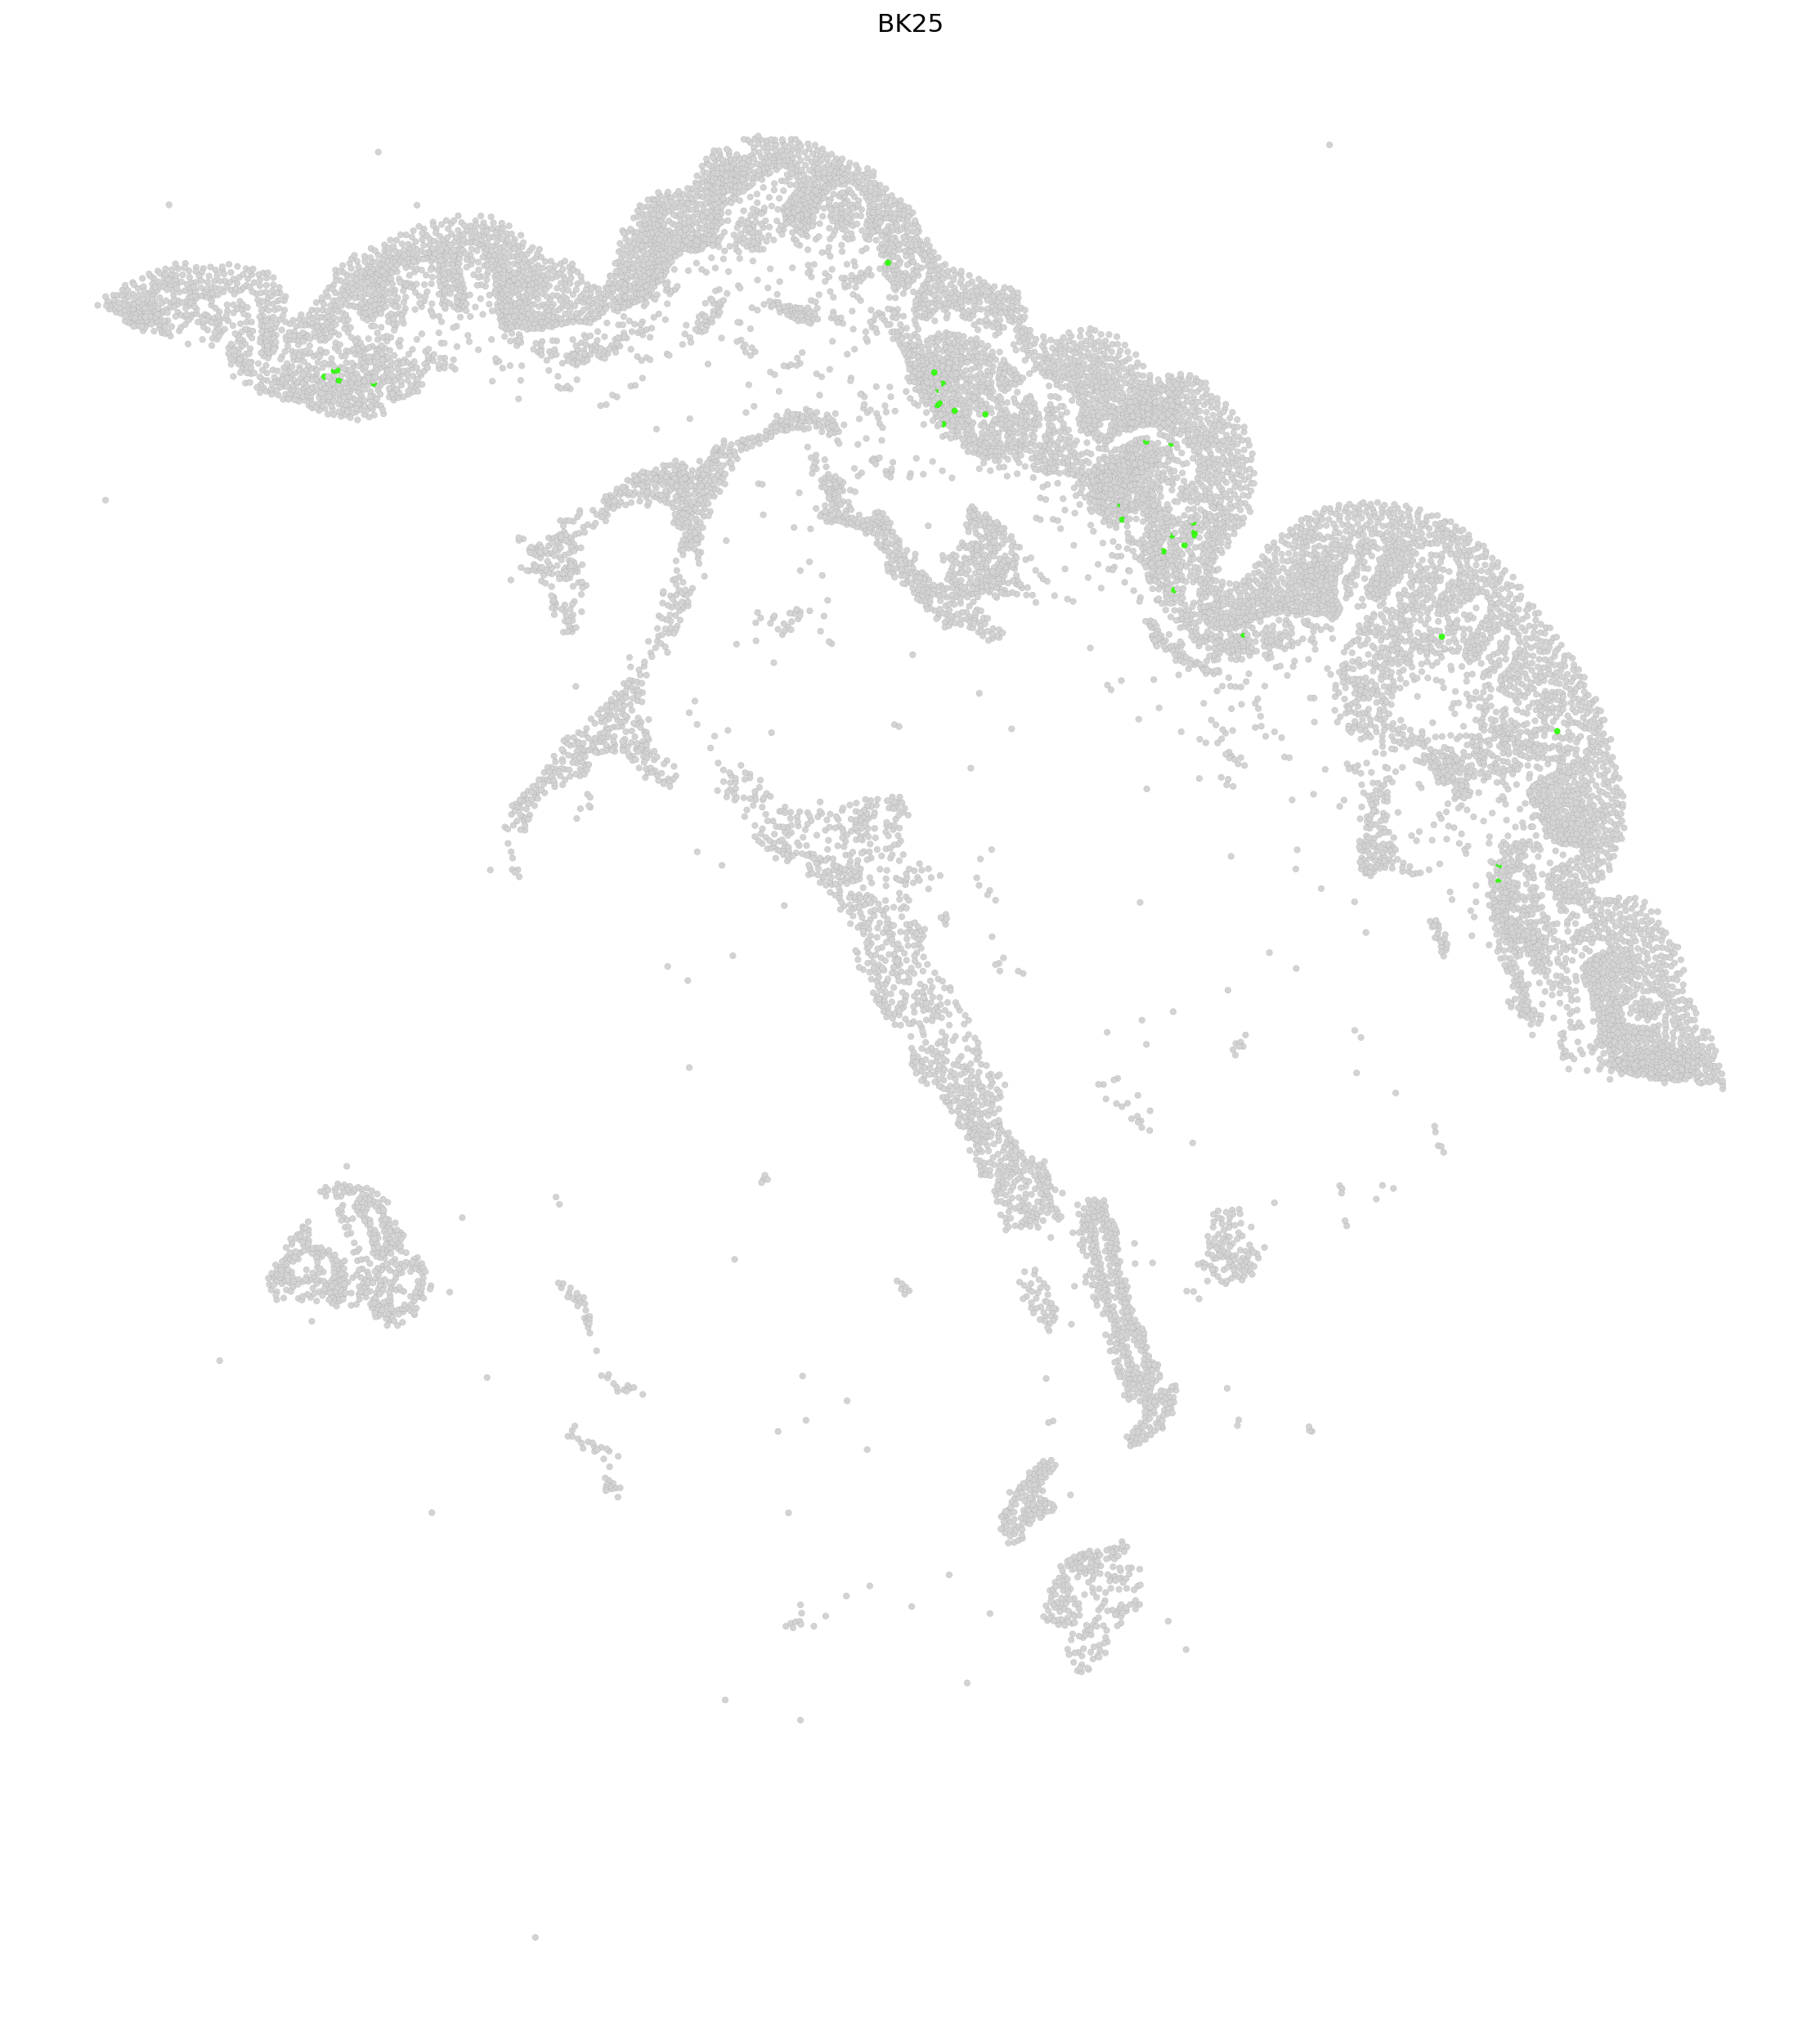

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


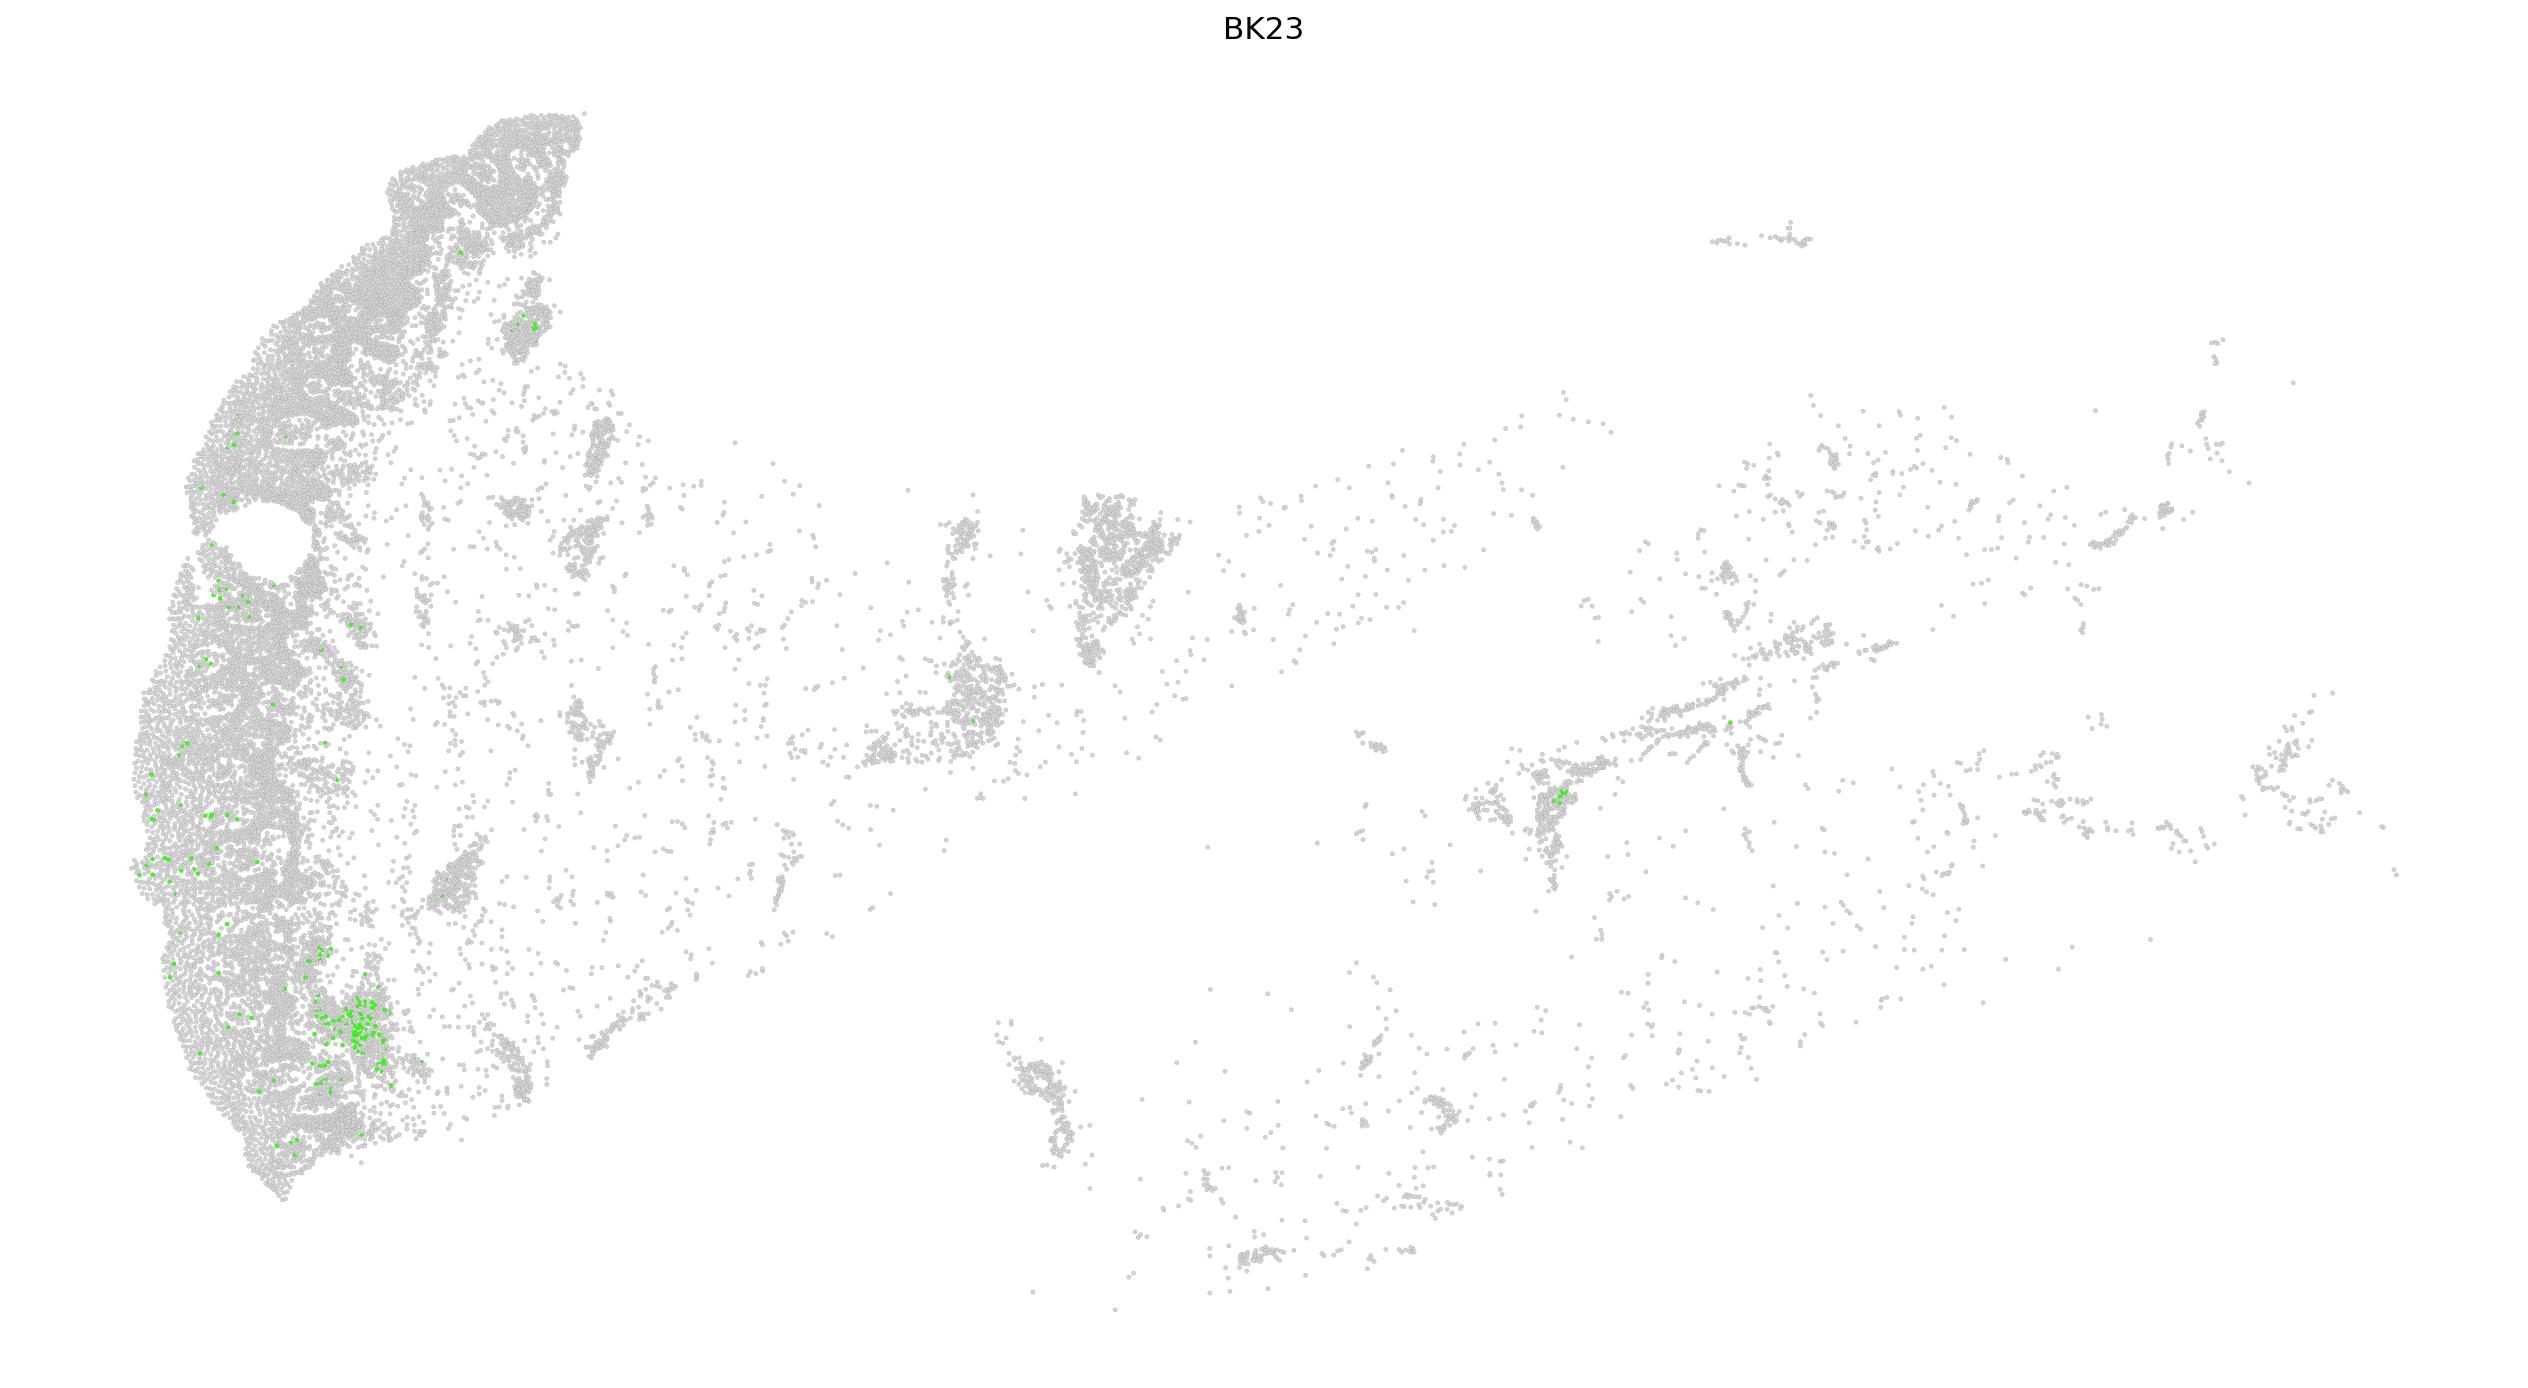

In [19]:


target = "MigDC (cDC2)"
highlight_color = "#39FF14"   # neon green
background_color = "#D3D3D3"  # light grey

adata_filt = adata[adata.obs["Site_status"] == "Non-lesional"]

#for x in adata_filt.obs["Sanger patient ID"].unique():
for x in ['BK39', 'BK25', 'BK23']:
    adata_i = adata_filt[adata_filt.obs["Sanger patient ID"] == x].copy()

    # Make a binary annotation column
    adata_i.obs["highlight"] = [
        target if y == target else "Other" 
        for y in adata_i.obs["lvl5_annotation"]
    ]
    adata_i.obs["highlight"] = adata_i.obs["highlight"].astype("category")

    # Assign colors: one for target, one for all others
    adata_i.uns["highlight_colors"] = [highlight_color, background_color]

    sc.pl.spatial(
        adata_i,
        color="highlight",
        spot_size=12,
        vmax=1,
        edgecolor="black",
        linewidth=0.03,
        legend_fontsize=12,
        title=x,
        legend_loc=None,
        save=f"3k_nonlesional_{x}.pdf"
    )

In [20]:
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(20,20))

# target = "MigDC (cDC2)"
# highlight_color = "#39FF14"   # neon green
# background_color = "#D3D3D3"  # light grey

# adata_filt = adata[adata.obs["Site_status"] == "Non-lesional"]

# for x in ['BK39', 'BK25', 'BK23']:
#     adata_i = adata_filt[adata_filt.obs["Sanger patient ID"] == x].copy()

#     # Make a binary annotation column
#     adata_i.obs["highlight"] = [
#         target if y == target else "Other" 
#         for y in adata_i.obs["lvl5_annotation"]
#     ]
#     adata_i.obs["highlight"] = adata_i.obs["highlight"].astype("category")

#     # Assign colors: one for target, one for all others
#     adata_i.uns["highlight_colors"] = [highlight_color, background_color]

#     sc.pl.spatial(
#         adata_i,
#         color="highlight",
#         spot_size=12,
#         vmax=1,
#         edgecolor="black",
#         linewidth=0.03,
#         legend_fontsize=12,
#         title=x,
#         legend_loc=None
#     )

In [21]:
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(20,20))

# target = "TRM_IL13+"
# highlight_color = "#D3D3D3"    # neon green
# background_color = "#0000CD"   # light grey

# adata_filt = adata[adata.obs["Site_status"] == "Week 12"]

# for x in ['BK39', 'BK25', 'BK23']:
#     adata_i = adata_filt[adata_filt.obs["Sanger patient ID"] == x].copy()

#     # Make a binary annotation column
#     adata_i.obs["highlight"] = [
#         target if y == target else "Other" 
#         for y in adata_i.obs["lvl5_annotation"]
#     ]
    
#     adata_i.obs["highlight"] = adata_i.obs["highlight"].astype("category")

#     # Assign colors: one for target, one for all others
#     adata_i.uns["highlight_colors"] = [highlight_color, background_color]

#     sc.pl.spatial(
#         adata_i,
#         color="highlight",
#         spot_size=12,
#         vmax=1,
#         edgecolor="black",
#         linewidth=0.03,
#         legend_fontsize=12,
#         title=x,
#         legend_loc=None
#     )